# Phase 4: Model Comparison & Ablation Studies
This notebook runs comparative model evaluation, ablation studies, logical reasoning benchmarks, and produces the comprehensive dashboard.

**Prerequisite:** Run Notebook 03 first — it loads the model, retrieval pipeline, and benchmark data.

**Note:** This notebook re-establishes the necessary state from Notebook 03. All cells are self-contained.

## Environment Setup
Re-establish shared state from Notebook 03.

In [ ]:
%pip -q install "langchain-community>=0.2.0" "langchain-core>=0.2.0" "rank_bm25>=0.2.2" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "transformers>=4.40.0" "datasets>=2.18.0" "torch>=2.0.0" "sentence-transformers>=2.2.0" "faiss-cpu>=1.7.4" "psutil>=5.9.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "accelerate>=0.29.0"

In [ ]:
# Project Root and Imports
import os, sys, re, json, time, gc
from pathlib import Path
from typing import Dict, List, Tuple, Callable, Optional, Any

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sns.set_theme(style="whitegrid")

# Model presets
MODEL_PRESETS: Dict[str, str] = {
    "phi3-mini": "microsoft/Phi-3-mini-4k-instruct",
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B-Instruct",
    "tinyllama-1.1b": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "mistral-7b": "mistralai/Mistral-7B-Instruct-v0.3",
}

def resolve_model_id(model_key_or_id: str) -> str:
    return MODEL_PRESETS.get(model_key_or_id, model_key_or_id)

def detect_backend():
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

backend = detect_backend()
assert backend == "cuda", f"CUDA GPU required. Detected: {backend}"
device = torch.device("cuda")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Backend: {backend}")


## Benchmark Data & Retrieval Functions
Re-load benchmark cases and retrieval pipeline from Notebook 03.

In [ ]:
# --- Evaluation utility functions ---
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

def lexical_overlap_score(query: str, text: str) -> float:
    q = set(re.findall(r"[A-Za-z0-9$.]+", query.lower()))
    t = set(re.findall(r"[A-Za-z0-9$.]+", text.lower()))
    return len(q & t) / len(q) if q else 0.0

def char_ngram_jaccard(query: str, text: str, n: int = 3) -> float:
    def grams(s):
        s = re.sub(r"\s+", " ", s.lower()).strip()
        return {s[i:i+n] for i in range(max(1, len(s)-n+1))}
    qg, tg = grams(query), grams(text)
    return len(qg & tg) / max(1, len(qg | tg))

try:
    from sentence_transformers import CrossEncoder
    CROSS_ENCODER_AVAILABLE = True
    cross_encoder_model = None
except ImportError:
    CROSS_ENCODER_AVAILABLE = False
    cross_encoder_model = None

def initialize_cross_encoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"):
    global cross_encoder_model
    if not CROSS_ENCODER_AVAILABLE:
        return False
    cross_encoder_model = CrossEncoder(model_name)
    return True

def rerank_chunks(query, chunks, use_cross_encoder=True):
    if use_cross_encoder and CROSS_ENCODER_AVAILABLE and cross_encoder_model is not None:
        pairs = [(query, chunk) for chunk in chunks]
        scores = cross_encoder_model.predict(pairs)
        scored = sorted(zip(chunks, scores), key=lambda x: x[1], reverse=True)
        return [c for c, _ in scored], [(c, float(s)) for c, s in scored]
    scored = [(chunk, lexical_overlap_score(query, chunk)) for chunk in chunks]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in scored], scored

# rerank=False: ms-marco cross-encoder hurts financial domain (not domain-adapted)
def retrieval_metrics(cases, retrieval_fn, rerank=False, top_n=8):
    recall_at = {1: 0, 3: 0, 5: 0}
    rrs = []
    for case in cases:
        gold = case.get("gold_chunk", case.get("gold_answer", "")).lower().strip()
        candidates = retrieval_fn(case["query"], top_n)
        if rerank:
            candidates, _ = rerank_chunks(case["query"], candidates)
        found_rank = None
        for rank, chunk in enumerate(candidates):
            if gold in chunk.lower() or chunk.lower() in gold:
                found_rank = rank + 1
                break
            gold_nums = set(re.findall(r'[\d.]+', gold))
            chunk_nums = set(re.findall(r'[\d.]+', chunk.lower()))
            if gold_nums and gold_nums & chunk_nums:
                found_rank = rank + 1
                break
        for k in recall_at:
            if found_rank and found_rank <= k:
                recall_at[k] += 1
        rrs.append(1.0/found_rank if found_rank else 0.0)
    n = len(cases)
    return {"Recall@1": recall_at[1]/n, "Recall@3": recall_at[3]/n, "Recall@5": recall_at[5]/n, "MRR": np.mean(rrs)} if n else {}

def faithfulness_binary(answer, context):
    if not answer or not context:
        return 0.0
    a_terms = set(re.findall(r'[A-Za-z0-9.]+', answer.lower())) - {'the','is','at','which','on','a','an','and','or','was','were','be','been'}
    c_terms = set(re.findall(r'[A-Za-z0-9.]+', context.lower()))
    return 1.0 if (not a_terms or len(a_terms & c_terms)/len(a_terms) >= 0.5) else 0.0

def calculate_ssov(target_entity, response):
    if not target_entity or not response:
        return 0.0
    words = response.lower().split()
    target_words = [w for w in words if target_entity.lower() in w or w in target_entity.lower()]
    return len(target_words) / max(1, len(words))

def aggregate_generation_results(rows):
    if not rows:
        return {"SSoV": 0, "ExactMatch": 0, "Faithfulness": 0, "TTFT_ms": 0, "Latency_ms": 0, "Throughput_tps": 0}
    return {
        "SSoV": np.mean([r.get("ssov", 0) for r in rows]),
        "ExactMatch": np.mean([r.get("exact_match", 0) for r in rows]),
        "Faithfulness": np.mean([r.get("faithful", 0) for r in rows]),
        "TTFT_ms": np.mean([r.get("ttft_ms", 0) for r in rows]),
        "Latency_ms": np.mean([r.get("latency_ms", 0) for r in rows]),
        "Throughput_tps": np.mean([r.get("throughput_tps", 0) for r in rows]),
    }

def fallback_generate_answer(query, context):
    if not context:
        return "No context available."
    sentences = re.split(r'[.\n]+', context)
    q_tokens = set(query.lower().split())
    best, best_score = "", -1
    for s in sentences:
        s = s.strip()
        if not s: continue
        score = len(q_tokens & set(s.lower().split()))
        if score > best_score:
            best_score, best = score, s
    return best or sentences[0].strip()

print("Utility functions loaded.")

In [ ]:
# --- Runtime configuration ---
ACTIVE_SLM_KEY = "phi3-mini"
BASE_MODEL_KEY = "phi3-mini"
COMPARISON_7B_KEY = "mistral-7b"
ENABLE_MODEL_GENERATION = True
MAX_BENCHMARK_CASES = 100
TOP_N_RETRIEVAL = 8

active_model_id = resolve_model_id(ACTIVE_SLM_KEY)
base_model_id = resolve_model_id(BASE_MODEL_KEY)
comparison_7b_id = resolve_model_id(COMPARISON_7B_KEY)

# --- Load FinQA benchmark data ---
def _row_to_text(row):
    return " | ".join(str(x) for x in row) if isinstance(row, list) else str(row)

def build_benchmark_from_finqa_json(path, max_cases=100):
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    cases, corpus = [], []
    for item in raw:
        qa = item.get("qa", {})
        question = str(qa.get("question", "")).strip()
        answer = str(qa.get("answer", "")).strip()
        if not question or not answer:
            continue
        table = item.get("table", [])
        pre_text = item.get("pre_text", [])
        post_text = item.get("post_text", [])
        table_lines = [_row_to_text(r) for r in table] if isinstance(table, list) else []
        text_lines = ([str(x) for x in pre_text] if isinstance(pre_text, list) else []) + \
                     ([str(x) for x in post_text] if isinstance(post_text, list) else [])
        gold_chunk = next((ln for ln in table_lines + text_lines if answer.lower() in ln.lower()),
                         table_lines[1] if len(table_lines) > 1 else (text_lines[0] if text_lines else answer))
        cases.append({"query": question, "gold_chunk": gold_chunk, "gold_answer": answer, "target_entity": answer})
        for row in (table if isinstance(table, list) else []):
            corpus.append(_row_to_text(row))
        corpus.extend([str(x) for x in pre_text] if isinstance(pre_text, list) else [])
        corpus.extend([str(x) for x in post_text] if isinstance(post_text, list) else [])
        if len(cases) >= max_cases:
            break
    return cases, list(dict.fromkeys([c for c in corpus if isinstance(c, str) and c.strip()]))

benchmark_cases, benchmark_corpus = build_benchmark_from_finqa_json(
    path=f"data/finQA/test.json", max_cases=MAX_BENCHMARK_CASES
)
print(f"Benchmark cases: {len(benchmark_cases)} | Corpus chunks: {len(benchmark_corpus)}")

# Dense retrieval init
try:
    from sentence_transformers import SentenceTransformer
    import faiss
    DENSE_AVAILABLE = True
except ImportError:
    DENSE_AVAILABLE = False

dense_encoder = faiss_index = dense_corpus = None

def initialize_dense_retrieval(corpus, model_name="all-MiniLM-L6-v2"):
    global dense_encoder, faiss_index, dense_corpus
    if not DENSE_AVAILABLE: return False
    dense_encoder = SentenceTransformer(model_name)
    dense_corpus = corpus
    embeddings = dense_encoder.encode(corpus, show_progress_bar=True, convert_to_numpy=True)
    faiss_index = faiss.IndexFlatL2(embeddings.shape[1])
    faiss_index.add(embeddings.astype('float32'))
    print(f"FAISS index: {faiss_index.ntotal} vectors")
    return True

def dense_retrieve(query, top_k=5):
    if not DENSE_AVAILABLE or faiss_index is None: return []
    q_emb = dense_encoder.encode([query], convert_to_numpy=True).astype('float32')
    D, I = faiss_index.search(q_emb, top_k)
    return [(dense_corpus[i], float(D[0][j])) for j, i in enumerate(I[0]) if i < len(dense_corpus)]

if DENSE_AVAILABLE and benchmark_corpus:
    initialize_dense_retrieval(benchmark_corpus)

# dense is default: best Recall@5 (0.55 vs hybrid 0.46, sparse 0.37)
def get_candidates(query, method="dense", top_n=8):
    if method == "sparse":
        return sorted(benchmark_corpus, key=lambda t: lexical_overlap_score(query, t), reverse=True)[:top_n]
    if method == "dense":
        if DENSE_AVAILABLE and faiss_index is not None:
            return [doc for doc, _ in dense_retrieve(query, top_n)]
        return sorted(benchmark_corpus, key=lambda t: char_ngram_jaccard(query, t), reverse=True)[:top_n]
    # Hybrid: RRF
    sparse = sorted([(t, lexical_overlap_score(query, t)) for t in benchmark_corpus], key=lambda x: x[1], reverse=True)[:top_n]
    if DENSE_AVAILABLE and faiss_index is not None:
        dense_res = dense_retrieve(query, top_n)
    else:
        dense_res = sorted([(t, char_ngram_jaccard(query, t)) for t in benchmark_corpus], key=lambda x: x[1], reverse=True)[:top_n]
    fused = {}
    for rank, (t, _) in enumerate(sparse):
        fused.setdefault(t, 0.0)
        fused[t] += 1.0 / (rank + 1)
    for rank, (t, _) in enumerate(dense_res):
        fused.setdefault(t, 0.0)
        fused[t] += 1.0 / (rank + 1)
    return [t for t, _ in sorted(fused.items(), key=lambda x: x[1], reverse=True)][:top_n]

print("Retrieval pipeline ready.  [default: dense, no reranking]")

## Model Loading
Load the fine-tuned model for comparative evaluation.

In [ ]:
# -----------------------------
# Baseline and Fine-tuned Model Loading with Memory Management
# -----------------------------
import torch
import gc
import os
from typing import Optional, Tuple

# Set environment variables for better memory management
if torch.cuda.is_available():
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Model instances
active_model = None
active_tokenizer = None
base_model = None
base_tokenizer = None

# Paths to fine-tuned model artifacts (from notebook 2)
FINETUNED_MODEL_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "finetuned_model"    # Merged model
ADAPTER_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "fingeo-slm-adapter"          # LoRA adapter

# Memory management configuration
USE_CPU_OFFLOAD = True
MAX_MEMORY = None

def clear_gpu_memory():
    """Clear GPU/device memory cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def get_available_gpu_memory():
    """Get available GPU memory in GB."""
    if torch.cuda.is_available():
        mem_free = torch.cuda.mem_get_info()[0] / 1024**3
        mem_total = torch.cuda.mem_get_info()[1] / 1024**3
        return mem_free, mem_total
    return 0, 0

def setup_max_memory():
    """Setup max memory configuration for device_map='auto'."""
    if not torch.cuda.is_available():
        return None
    
    mem_free, mem_total = get_available_gpu_memory()
    usable_memory = max(0, mem_free - 2.0)
    
    if usable_memory < 4.0:
        print(f"  Warning: Low GPU memory available: {mem_free:.2f}GB free")
        print(f"    Enabling CPU offloading...")
        max_memory = {
            0: f"{int(usable_memory * 0.9)}GiB",
            "cpu": "20GiB"
        }
    else:
        max_memory = {
            0: f"{int(usable_memory * 0.95)}GiB",
            "cpu": "10GiB"
        }
    return max_memory

def load_model_safe(
    model_id: str,
    model_name: str = "Model",
    force_cpu_offload: bool = False
) -> Tuple[Optional[object], Optional[object]]:
    """
    Safely load a model with proper error handling and memory management.
    Supports CUDA, MPS, and CPU backends.
    
    Args:
        model_id: HuggingFace model ID or local path
        model_name: Display name for logging
        force_cpu_offload: Force CPU offloading even if GPU has memory
        
    Returns:
        Tuple of (tokenizer, model) or (None, None) if loading fails
    """
    try:
        clear_gpu_memory()
        
        print(f"\n  Loading {model_name}: {model_id}...")
        
        if torch.cuda.is_available():
            mem_free, mem_total = get_available_gpu_memory()
            print(f"  GPU Memory: {mem_free:.2f}GB free / {mem_total:.2f}GB total")
        
        # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        # Check if accelerate is available
        has_accelerate = False
        try:
            import accelerate
            has_accelerate = True
        except ImportError:
            has_accelerate = False

        # Determine loading strategy based on backend
        if backend == "cuda":
            mem_free, _ = get_available_gpu_memory()
            model_size_gb = 7.0 if "7b" in model_id.lower() else 3.0
            
            if has_accelerate:
                if mem_free < model_size_gb + 2.0 or force_cpu_offload or USE_CPU_OFFLOAD:
                    print(f"  Using CPU offloading (low memory: {mem_free:.2f}GB)")
                    device_map = "auto"
                    max_memory = setup_max_memory()
                    torch_dtype = torch.float16
                    load_in_8bit = mem_free < 6.0
                else:
                    print(f"  Using full GPU loading")
                    device_map = "auto"
                    max_memory = None
                    torch_dtype = torch.float16
                    load_in_8bit = False
            else:
                print(f"  Using basic GPU loading (no accelerate)")
                device_map = None
                max_memory = None
                torch_dtype = torch.float16
                load_in_8bit = False
            
        elif backend == "mps":
            device_map = None
            max_memory = None
            torch_dtype = torch.float32
            load_in_8bit = False
            print(f"  Using MPS with float32")
        else:
            device_map = None
            max_memory = None
            torch_dtype = torch.float32
            load_in_8bit = False
            print(f"  Using CPU with float32")
        
        # Load model
        load_kwargs = {
            "torch_dtype": torch_dtype,
            "trust_remote_code": False,
            "low_cpu_mem_usage": True
        }
        
        if device_map is not None:
            load_kwargs["device_map"] = device_map
        
        if max_memory:
            load_kwargs["max_memory"] = max_memory
        
        if load_in_8bit and backend == "cuda":
            print(f"  Enabling 8-bit quantization for memory efficiency")
            quantization_config = BitsAndBytesConfig(load_in_8bit=True)
            load_kwargs["quantization_config"] = quantization_config
        
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            **load_kwargs
        )
        
        # Move to device if not using device_map
        if device_map is None:
            if backend == "mps":
                model = model.to("mps")
            elif backend == "cuda":
                model = model.to("cuda")
            # CPU is the default, no move needed
        
        # Print model info
        num_params = sum(p.numel() for p in model.parameters())
        print(f"  Loaded {model_name}")
        print(f"    Parameters: {num_params:,} ({num_params/1e9:.2f}B)")
        
        if torch.cuda.is_available():
            mem_free_after, _ = get_available_gpu_memory()
            mem_used = mem_free - mem_free_after
            print(f"    GPU Memory used: {mem_used:.2f}GB")
            print(f"    GPU Memory remaining: {mem_free_after:.2f}GB")
        
        return tokenizer, model
        
    except Exception as e:
        print(f"  Failed to load {model_name}")
        print(f"     Error type: {type(e).__name__}")
        print(f"     Error message: {str(e)}")
        import traceback
        traceback.print_exc()
        print(f"    Continuing without {model_name}...")
        clear_gpu_memory()
        return None, None

def unload_model(model, tokenizer, model_name: str = "Model"):
    """Safely unload a model and free memory."""
    if model is not None:
        print(f"\n  Unloading {model_name}...")
        del model
        del tokenizer
        clear_gpu_memory()
        
        if torch.cuda.is_available():
            mem_free, mem_total = get_available_gpu_memory()
            print(f"  Memory freed. Available: {mem_free:.2f}GB / {mem_total:.2f}GB")

if ENABLE_MODEL_GENERATION:
    print("="*80)
    print("MODEL LOADING WITH MEMORY MANAGEMENT")
    print("="*80)
    
    if torch.cuda.is_available():
        mem_free, mem_total = get_available_gpu_memory()
        print(f"\nInitial GPU Memory: {mem_free:.2f}GB free / {mem_total:.2f}GB total")
    
    # === Strategy: Try merged model first, then LoRA adapter, then base from HF ===
    from pathlib import Path
    
    merged_path = Path(FINETUNED_MODEL_PATH)
    adapter_path = Path(ADAPTER_PATH)
    
    if merged_path.exists():
        # --- Option 1: Load merged model directly ---
        print(f"\nFound merged model at: {merged_path}")
        print("Loading merged fine-tuned model directly (no adapter needed)...")
        active_tokenizer, active_model = load_model_safe(
            str(merged_path),
            "Fine-tuned Model (merged)"
        )
    elif adapter_path.exists():
        # --- Option 2: Load base model + apply LoRA adapter ---
        print(f"\nFound LoRA adapter at: {adapter_path}")
        print("Loading base model + applying LoRA adapter...")
        base_tokenizer_temp, base_model_temp = load_model_safe(
            active_model_id,
            "Base Model for LoRA"
        )
        
        if base_model_temp is not None:
            try:
                from peft import PeftModel
                print(f"  Loading LoRA adapter...")
                base_model_temp = PeftModel.from_pretrained(base_model_temp, str(adapter_path))
                print(f"  Merging adapter with base model...")
                base_model_temp = base_model_temp.merge_and_unload()
                print(f"  LoRA adapter loaded and merged successfully")
                active_tokenizer, active_model = base_tokenizer_temp, base_model_temp
            except Exception as e:
                print(f"  Failed to load LoRA adapter: {e}")
                print(f"  Using base model instead")
                active_tokenizer, active_model = base_tokenizer_temp, base_model_temp
        else:
            print(f"  Failed to load base model for LoRA")
            active_tokenizer, active_model = None, None
    else:
        # --- Option 3: Load base model from HuggingFace ---
        print(f"\nNo local fine-tuned model found.")
        print(f"  Checked: {merged_path}")
        print(f"  Checked: {adapter_path}")
        print(f"  Loading base {ACTIVE_SLM_KEY} from HuggingFace instead...")
        active_tokenizer, active_model = load_model_safe(
            active_model_id,
            f"Active SLM ({ACTIVE_SLM_KEY})"
        )
    
    # Baseline model: deferred loading
    print(f"\n{'='*80}")
    print("DEFERRED BASELINE LOADING")
    print("="*80)
    print("  Baseline model will be loaded only when needed for comparison")
    print(f"  Baseline: {base_model_id}")
    
    print("\n" + "="*80)
    print("MODEL LOADING SUMMARY")
    print("="*80)
    print(f"Active Model:   {'Loaded' if active_model else 'Not loaded'}")
    print(f"Baseline Model: Deferred (will load when needed)")
    
    if active_model:
        print(f"\n  Ready for evaluation!")
    else:
        print(f"\n  Warning: Active model failed to load - using fallback generation only")
        ENABLE_MODEL_GENERATION = True
else:
    print("  Model generation disabled (ENABLE_MODEL_GENERATION = False)")
    print(f"  Active SLM would be: {active_model_id}")
    print(f"  Baseline would be: {base_model_id}")


## Generation Functions

In [13]:
def model_generate_answer(query: str, context: str, tok, mdl, enable_cot: bool = True) -> str:
    """Model-based answer generation with Chain-of-Thought reasoning using Phi-3 format."""
    if enable_cot:
        prompt = (
            "<|user|>\n"
            "You are a highly accurate financial AI. Use the provided context to answer step-by-step.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}\n\n"
            "Let's think step by step.<|end|>\n"
            "<|assistant|>\n"
            "Reasoning:"
        )
    else:
        prompt = (
            "<|user|>\n"
            "You are a financial QA assistant. Use only the provided context.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}<|end|>\n"
            "<|assistant|>\n"
            "Answer:"
        )
    
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=2048)
    if backend == "mps":
        inputs = {k: v.to("mps") for k, v in inputs.items()}
        mdl = mdl.to("mps")
    elif backend == "cuda":
        inputs = {k: v.to("cuda") for k, v in inputs.items()}

    output_ids = mdl.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7, top_p=0.9)
    decoded = tok.decode(output_ids[0], skip_special_tokens=True)
    
    # Extract the generated part (after the prompt)
    if enable_cot and "Reasoning:" in decoded:
        answer = decoded.split("Reasoning:", 1)[-1].strip()
    elif "Answer" in decoded:
        answer = decoded.split("Answer", 1)[-1].strip()
    else:
        # Return everything after the prompt
        answer = decoded[len(prompt):].strip() if len(decoded) > len(prompt) else decoded.strip()
    
    # Remove any trailing special tokens
    answer = answer.replace("<|end|>", "").strip()
    return answer

print("Generation functions defined.")


Generation functions defined.


In [ ]:
# -----------------------------
# Reasoning Extraction Utilities
# -----------------------------
import re

def extract_reasoning_and_answer(generated_text: str) -> dict:
    """
    Extract reasoning steps and final answer from generated text.
    
    Returns:
        dict with 'reasoning', 'final_answer', and 'full_text' keys
    """
    result = {
        'reasoning': '',
        'final_answer': '',
        'full_text': generated_text.strip()
    }
    
    # Try to split on "Final Answer:" marker
    if 'Final Answer:' in generated_text:
        parts = generated_text.split('Final Answer:', 1)
        result['reasoning'] = parts[0].strip()
        result['final_answer'] = parts[1].strip()
    # Try other common patterns
    elif 'Answer:' in generated_text and len(generated_text.split('Answer:', 1)) == 2:
        parts = generated_text.split('Answer:', 1)
        result['reasoning'] = parts[0].strip()
        result['final_answer'] = parts[1].strip()
    else:
        # No clear split - try to identify numeric answer at the end
        # Look for patterns like "= value" or "result: value" at the end
        lines = generated_text.strip().split('\n')
        if len(lines) > 1:
            result['reasoning'] = '\n'.join(lines[:-1]).strip()
            result['final_answer'] = lines[-1].strip()
        else:
            result['final_answer'] = generated_text.strip()
    
    return result


def format_reasoning_output(reasoning_dict: dict, query: str = None) -> str:
    """
    Format reasoning and answer for display.
    """
    output = []
    
    if query:
        output.append(f"❓ Question: {query}")
        output.append("")
    
    if reasoning_dict['reasoning']:
        output.append("🧠 Reasoning Steps:")
        output.append(reasoning_dict['reasoning'])
        output.append("")
    
    if reasoning_dict['final_answer']:
        output.append("✅ Final Answer:")
        output.append(reasoning_dict['final_answer'])
    else:
        output.append("📝 Generated Output:")
        output.append(reasoning_dict['full_text'])
    
    return '\n'.join(output)


def display_reasoning(generated_text: str, query: str = None):
    """
    Parse and display reasoning from generated text.
    """
    parsed = extract_reasoning_and_answer(generated_text)
    formatted = format_reasoning_output(parsed, query)
    print(formatted)
    return parsed


# Enable CoT by default globally
ENABLE_COT_REASONING = True
print("✓ Reasoning extraction utilities loaded")
print(f"✓ Chain-of-Thought reasoning: {'ENABLED' if ENABLE_COT_REASONING else 'DISABLED'} (default)")


In [ ]:
def build_model_generator(model_id: str) -> Tuple[object, object]:
    """
    Build model and tokenizer for generation (wrapper for load_model_safe).
    
    Args:
        model_id: HuggingFace model ID or local path
        
    Returns:
        Tuple of (tokenizer, model)
    """
    tokenizer, model = load_model_safe(model_id, model_name=model_id.split('/')[-1])
    
    if tokenizer is None or model is None:
        raise RuntimeError(f"Failed to load model: {model_id}")
    
    return tokenizer, model


print("✓ build_model_generator function defined")


In [ ]:
def extract_final_answer(text: str) -> str:
    """Extract the final answer from model output."""
    if not text:
        return ""
    if "Final Answer:" in text:
        answer = text.split("Final Answer:")[-1].strip()
        answer = answer.replace("<|end|>", "").strip()
        return answer
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    return lines[-1] if lines else text

def calculate_semantic_similarity(text1: str, text2: str) -> float:
    """Calculate similarity between two texts using Jaccard on tokens."""
    answer1 = extract_final_answer(text1)
    answer2 = extract_final_answer(text2)
    tokens1 = set(re.findall(r"[A-Za-z0-9.]+", answer1.lower()))
    tokens2 = set(re.findall(r"[A-Za-z0-9.]+", answer2.lower()))
    if not tokens1 and not tokens2:
        return 1.0
    if not tokens1 or not tokens2:
        return 0.0
    return len(tokens1 & tokens2) / len(tokens1 | tokens2)

print("Answer extraction and similarity functions loaded.")

In [ ]:
# =============================================================================
# MODEL EVALUATION FUNCTIONS
# =============================================================================
import re
import time
from typing import Dict, List, Callable, Optional, Tuple, Any


def extract_first_number(text: str) -> str:
    """Extract the first number from text."""
    if not text:
        return ""
    for pattern in [r'\$?[\d,]+\.?\d*[BMK]?%?', r'[\d,]+\.?\d*']:
        match = re.search(pattern, text)
        if match:
            return match.group(0).lower().strip().replace(',', '').replace('$', '')
    return ""


def numeric_match(pred: str, gold: str, tol: float = 0.02) -> bool:
    """Tolerant numeric comparison — 2% relative error counts as correct."""
    try:
        p = float(pred.replace('%', '').replace('b', 'e9').replace('m', 'e6').replace('k', 'e3'))
        g = float(gold.replace('%', '').replace('b', 'e9').replace('m', 'e6').replace('k', 'e3'))
        return abs(p - g) / max(abs(g), 1e-8) <= tol
    except (ValueError, ZeroDivisionError):
        return pred.strip() == gold.strip()


def build_prompt(tokenizer: Any, query: str, context: str) -> str:
    """Build a prompt using the tokenizer's chat template when available,
    otherwise fall back to a plain format. This is critical for fine-tuned
    models that were trained with a specific chat format (e.g. Phi-3, Qwen2.5).
    """
    user_content = (
        "You are a financial analysis assistant. "
        "Use the context below to answer the question precisely. "
        "Think step by step, then write the final numerical answer on the last line.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}"
    )

    if hasattr(tokenizer, 'chat_template') and tokenizer.chat_template:
        try:
            messages = [{"role": "user", "content": user_content}]
            return tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        except Exception:
            pass  # fall through to raw format

    return f"{user_content}\n\nAnswer:"


def evaluate_model_on_cases(
    model: Any,
    tokenizer: Any,
    cases: List[Dict],
    retrieval_fn: Callable,
    model_name: str = "Model",
    max_cases: int = 50
) -> Dict:
    """Evaluate a model on benchmark cases."""
    import torch

    results = {
        'model_name': model_name,
        'total_cases': 0,
        'exact_matches': 0,
        'partial_matches': 0,
        'ssov_scores': [],
        'latencies_ms': [],
        'faithfulness_scores': [],
        'details': []
    }

    eval_cases = cases[:max_cases]
    results['total_cases'] = len(eval_cases)

    print(f"\n  Evaluating {model_name} on {len(eval_cases)} cases...")

    for i, case in enumerate(eval_cases):
        try:
            candidates = retrieval_fn(case['query'], TOP_N_RETRIEVAL)
            context = "\n---\n".join(candidates[:3]) if candidates else ""

            # Use chat template if available (critical for fine-tuned models)
            prompt = build_prompt(tokenizer, case['query'], context)

            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
            device = next(model.parameters()).device
            inputs = {k: v.to(device) for k, v in inputs.items()}

            start_time = time.time()
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=tokenizer.eos_token_id
                )
            latency_ms = (time.time() - start_time) * 1000

            new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
            answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

            final_ans = extract_final_answer(answer)
            pred_num = extract_first_number(final_ans)
            gold_num = extract_first_number(case['gold_answer'])
            exact_match = numeric_match(pred_num, gold_num) if pred_num and gold_num else False

            target = case.get('target_entity', case['gold_answer'])
            ssov = 1.0 if target.lower() in answer.lower() else 0.0
            faithful = faithfulness_binary(answer, context) if context else 0.0

            if exact_match:
                results['exact_matches'] += 1

            results['ssov_scores'].append(ssov)
            results['latencies_ms'].append(latency_ms)
            results['faithfulness_scores'].append(faithful)

            results['details'].append({
                'query': case['query'][:50],
                'gold': case['gold_answer'],
                'predicted': final_ans[:100],
                'pred_num': pred_num,
                'gold_num': gold_num,
                'exact_match': exact_match,
                'ssov': ssov,
                'latency_ms': latency_ms
            })

            if (i + 1) % 10 == 0:
                print(f"    Progress: {i+1}/{len(eval_cases)}")

        except Exception as e:
            print(f"    Warning: Error on case {i}: {e}")
            results['details'].append({'query': case['query'][:50], 'error': str(e)})

    n = results['total_cases']
    results['accuracy'] = results['exact_matches'] / n if n > 0 else 0
    results['avg_ssov'] = sum(results['ssov_scores']) / len(results['ssov_scores']) if results['ssov_scores'] else 0
    results['avg_latency_ms'] = sum(results['latencies_ms']) / len(results['latencies_ms']) if results['latencies_ms'] else 0
    results['avg_faithfulness'] = sum(results['faithfulness_scores']) / len(results['faithfulness_scores']) if results['faithfulness_scores'] else 0

    print(f"  ✓ {model_name}: Accuracy={results['accuracy']:.2%}, SSoV={results['avg_ssov']:.3f}, Latency={results['avg_latency_ms']:.1f}ms")
    return results


def faithfulness_binary(answer: str, context: str) -> float:
    """Check if answer is supported by context (binary)."""
    if not answer or not context:
        return 0.0
    answer_terms = set(re.findall(r'[A-Za-z0-9.]+', answer.lower()))
    context_terms = set(re.findall(r'[A-Za-z0-9.]+', context.lower()))
    stopwords = {'the', 'is', 'at', 'which', 'on', 'a', 'an', 'and', 'or', 'was', 'were', 'be', 'been'}
    answer_terms -= stopwords
    if not answer_terms:
        return 1.0
    return 1.0 if len(answer_terms & context_terms) / len(answer_terms) >= 0.5 else 0.0


print("✓ Model evaluation functions loaded:")
print("  - numeric_match()         [2% tolerance]")
print("  - build_prompt()          [auto chat-template for fine-tuned models]")
print("  - evaluate_model_on_cases()")
print("  - faithfulness_binary()")

In [ ]:
# -----------------------------
# Timing Helper Functions
# -----------------------------
import time

def time_call(func, *args, **kwargs):
    """
    Time a function call and return (result, execution_time_ms).
    
    Args:
        func: Function to call
        *args: Arguments to pass to function
        **kwargs: Keyword arguments to pass to function
    
    Returns:
        Tuple of (function_result, execution_time_in_ms)
    """
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    execution_time_ms = (end_time - start_time) * 1000  # Convert to milliseconds
    return result, execution_time_ms

def timed_generation_metrics(answer: str, call_duration_ms: float) -> dict:
    """
    Calculate generation performance metrics.
    
    Args:
        answer: Generated answer text
        call_duration_ms: Total generation time in milliseconds
    
    Returns:
        Dict with latency_ms and throughput_tps (tokens per second)
    """
    # Estimate token count (rough approximation: ~4 chars per token)
    estimated_tokens = len(answer) / 4.0
    
    # Calculate throughput (tokens per second)
    if call_duration_ms > 0:
        throughput_tps = (estimated_tokens / call_duration_ms) * 1000  # tokens per second
    else:
        throughput_tps = 0.0
    
    return {
        "latency_ms": call_duration_ms,
        "throughput_tps": throughput_tps
    }

print("✓ Timing helper functions loaded")


In [ ]:
def run_generation_eval(cases, retrieval_method: str = "dense", rerank: bool = False, generator=None):
    """Run generation evaluation across benchmark cases."""
    rows = []

    for case in cases:
        raw = get_candidates(case["query"], method=retrieval_method, top_n=TOP_N_RETRIEVAL)
        ranked = raw
        if rerank:
            ranked, _ = rerank_chunks(case["query"], raw)

        context = "\n---\n".join(ranked[:3])

        if generator is None:
            answer, ttft_ms = time_call(fallback_generate_answer, case["query"], context)
            _, total_latency_ms = time_call(fallback_generate_answer, case["query"], context)
        else:
            answer, ttft_ms = time_call(generator, case["query"], context)
            _, total_latency_ms = time_call(generator, case["query"], context)

        perf = timed_generation_metrics(answer=answer, call_duration_ms=total_latency_ms)

        final_ans = extract_final_answer(answer)
        pred_num = extract_first_number(final_ans)
        gold_num = extract_first_number(case["gold_answer"])
        em = int(numeric_match(pred_num, gold_num)) if pred_num and gold_num else 0

        ssov = float(case["target_entity"].lower() in answer.lower())
        faithful = faithfulness_binary(answer, context)

        rows.append(
            {
                "query": case["query"],
                "answer": answer,
                "ttft_ms": ttft_ms,
                "latency_ms": perf["latency_ms"],
                "throughput_tps": perf["throughput_tps"],
                "ssov": ssov,
                "exact_match": em,
                "faithful": faithful,
            }
        )

    return rows

print("Evaluation harness ready.  [default: dense retrieval, no reranking]")

In [ ]:
def extract_first_number(text):
    if not text: return ""
    for pattern in [r'\$?[\d,]+\.?\d*[BMK]?%?', r'[\d,]+\.?\d*']:
        match = re.search(pattern, text)
        if match:
            return match.group(0).lower().strip().replace(',', '').replace('$', '')
    return ""

def numeric_match(pred: str, gold: str, tol: float = 0.02) -> bool:
    try:
        p = float(pred.replace('%', '').replace('b', 'e9').replace('m', 'e6').replace('k', 'e3'))
        g = float(gold.replace('%', '').replace('b', 'e9').replace('m', 'e6').replace('k', 'e3'))
        return abs(p - g) / max(abs(g), 1e-8) <= tol
    except (ValueError, ZeroDivisionError):
        return pred.strip() == gold.strip()

print("extract_first_number and numeric_match loaded.")

In [ ]:
# Execute Comparative Evaluation (Sequential with Memory Management)
model_comparison_results = {}
EVAL_MAX_CASES = min(30, len(benchmark_cases))  # Limit cases to prevent OOM
eval_subset = benchmark_cases[:EVAL_MAX_CASES]

if not ENABLE_MODEL_GENERATION:
    raise RuntimeError("Model generation is disabled. Set ENABLE_MODEL_GENERATION = True")

print("="*80)
print(f"COMPARATIVE MODEL EVALUATION ({EVAL_MAX_CASES} cases)")
print("="*80)

# --- Evaluate Fine-tuned Model ---
if active_model is not None and active_tokenizer is not None:
    print("\nEvaluating fine-tuned model...")
    active_results = evaluate_model_on_cases(
        active_model, active_tokenizer, eval_subset,
        lambda q, top_n: get_candidates(q, "hybrid", top_n),
        model_name=f"Fine-tuned {ACTIVE_SLM_KEY}",
        max_cases=EVAL_MAX_CASES
    )
    model_comparison_results['finetuned'] = active_results

    # Unload active model before loading baseline
    print("\nUnloading fine-tuned model to free GPU memory...")
    unload_model(active_model, active_tokenizer, "Fine-tuned Model")
else:
    print("Fine-tuned model not available. Skipping.")

# --- Evaluate Baseline Model ---
print("\nLoading baseline model for comparison...")
clear_gpu_memory()

try:
    base_tok, base_mdl = load_model_safe(base_model_id, "Baseline Model")
    if base_mdl is not None:
        base_results = evaluate_model_on_cases(
            base_mdl, base_tok, eval_subset,
            lambda q, top_n: get_candidates(q, "hybrid", top_n),
            model_name=f"Baseline {BASE_MODEL_KEY}",
            max_cases=EVAL_MAX_CASES
        )
        model_comparison_results['baseline'] = base_results
        unload_model(base_mdl, base_tok, "Baseline Model")
        del base_mdl, base_tok
    else:
        print("Baseline model failed to load. Skipping comparison.")
except Exception as e:
    print(f"Baseline evaluation failed: {e}")

clear_gpu_memory()

# --- Reload fine-tuned model for remaining notebook ---
print("\nReloading fine-tuned model for remaining evaluations...")
if FINETUNED_MODEL_PATH.exists():
    active_tokenizer, active_model = load_model_safe(str(FINETUNED_MODEL_PATH), "Fine-tuned Model")
elif ADAPTER_PATH.exists():
    active_tokenizer, active_model = load_model_safe(active_model_id, "Base for LoRA")
    if active_model is not None:
        from peft import PeftModel
        active_model = PeftModel.from_pretrained(active_model, str(ADAPTER_PATH))
else:
    active_tokenizer, active_model = load_model_safe(active_model_id, f"Base {ACTIVE_SLM_KEY}")

# Print comparison summary
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)
for name, results in model_comparison_results.items():
    print(f"\n{name.upper()}:")
    print(f"  Accuracy:     {results['accuracy']:.2%}")
    print(f"  Avg SSoV:     {results['avg_ssov']:.3f}")
    print(f"  Avg Latency:  {results['avg_latency_ms']:.1f} ms")
    print(f"  Faithfulness: {results['avg_faithfulness']:.3f}")


## Comparative Model Visualizations

Visualize performance differences between fine-tuned SLM and baseline model.

In [ ]:
# 1. Model Performance Comparison - Overview

if model_comparison_results:
    available_keys = list(model_comparison_results.keys())

    if len(available_keys) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        models = available_keys[:2]
        model_names = [model_comparison_results[m]['model_name'] for m in models]
        colors = ['#2a9d8f', '#e76f51']

        # 1. Generation Latency Comparison
        gen_times = [model_comparison_results[m].get('avg_latency_ms', 0) for m in models]
        bars = axes[0, 0].bar(model_names, gen_times, color=colors, edgecolor='black', linewidth=2)
        axes[0, 0].set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
        axes[0, 0].set_title('Average Generation Latency\n(Lower is Better)', fontsize=12, fontweight='bold')
        axes[0, 0].grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, gen_times):
            if bar.get_height() > 0:
                axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                                f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold')

        # 2. Accuracy Comparison
        accuracies = [model_comparison_results[m].get('accuracy', 0) for m in models]
        bars = axes[0, 1].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=2)
        axes[0, 1].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
        axes[0, 1].set_title('Accuracy\n(Higher is Better)', fontsize=12, fontweight='bold')
        axes[0, 1].grid(axis='y', alpha=0.3)
        axes[0, 1].set_ylim(0, 1)
        for bar, val in zip(bars, accuracies):
            axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                            f'{val:.2%}', ha='center', va='bottom', fontweight='bold')

        # 3. Quality Metrics Comparison (SSoV + Faithfulness)
        ssovs = [model_comparison_results[m].get('avg_ssov', 0) for m in models]
        faithfulness = [model_comparison_results[m].get('avg_faithfulness', 0) for m in models]
        x = np.arange(len(model_names))
        width = 0.35
        axes[1, 0].bar(x - width/2, ssovs, width, label='SSoV', color='#264653', edgecolor='black')
        axes[1, 0].bar(x + width/2, faithfulness, width, label='Faithfulness', color='#e9c46a', edgecolor='black')
        axes[1, 0].set_ylabel('Score', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Quality Metrics\n(Higher is Better)', fontsize=12, fontweight='bold')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(model_names, rotation=15, ha='right')
        axes[1, 0].legend()
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].set_ylim(0, 1)

        # 4. Efficiency Score (combined quality / second)
        efficiency_scores = []
        for m in models:
            metrics = model_comparison_results[m]
            lat = metrics.get('avg_latency_ms', 0)
            if lat > 0:
                quality = metrics.get('accuracy', 0) + metrics.get('avg_ssov', 0)
                efficiency_scores.append(quality / (lat / 1000))
            else:
                efficiency_scores.append(0)
        bars = axes[1, 1].bar(model_names, efficiency_scores, color=colors, edgecolor='black', linewidth=2)
        axes[1, 1].set_ylabel('Efficiency Score', fontsize=11, fontweight='bold')
        axes[1, 1].set_title('Overall Efficiency\n(Quality/Second, Higher is Better)', fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, efficiency_scores):
            if bar.get_height() > 0:
                axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()
        print("✓ Model performance comparison visualization complete")
    else:
        print(f"⚠ Need at least 2 models for comparison. Available: {list(model_comparison_results.keys())}")
else:
    print("⚠ No model evaluation results available for visualization")
    print("  Run the comparative evaluation cell first.")

In [ ]:
# 2. Model Size vs Performance Trade-off Analysis

if model_comparison_results:
    model_sizes = {
        'phi3-mini': 3.8,
        'qwen2.5-1.5b': 1.5,
        'tinyllama-1.1b': 1.1,
        'mistral-7b': 7.0,
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sizes, qualities, speeds, labels, colors_list = [], [], [], [], []
    color_map = ['#2a9d8f', '#e76f51', '#264653', '#e9c46a']

    for i, (key, metrics) in enumerate(model_comparison_results.items()):
        model_key = ACTIVE_SLM_KEY if key == 'finetuned' else BASE_MODEL_KEY
        size = model_sizes.get(model_key, 3.0)
        quality = (metrics.get('accuracy', 0) + metrics.get('avg_ssov', 0)) / 2
        lat = metrics.get('avg_latency_ms', 1)
        speed = 1000.0 / lat if lat > 0 else 0

        sizes.append(size)
        qualities.append(quality)
        speeds.append(speed)
        labels.append(metrics['model_name'])
        colors_list.append(color_map[i % len(color_map)])

    if sizes:
        axes[0].scatter(sizes, qualities, s=400, c=colors_list, alpha=0.7, edgecolors='black', linewidth=2)
        for i, label in enumerate(labels):
            axes[0].annotate(label, (sizes[i], qualities[i]),
                             xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        axes[0].set_xlabel('Model Size (Billion Parameters)', fontsize=11, fontweight='bold')
        axes[0].set_ylabel('Average Quality Score', fontsize=11, fontweight='bold')
        axes[0].set_title('Model Size vs Quality\n(Top-left is better)', fontsize=12, fontweight='bold')
        axes[0].grid(alpha=0.3)
        axes[0].set_ylim(0, 1)

        axes[1].scatter(speeds, qualities, s=400, c=colors_list, alpha=0.7, edgecolors='black', linewidth=2)
        for i, label in enumerate(labels):
            axes[1].annotate(label, (speeds[i], qualities[i]),
                             xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        axes[1].set_xlabel('Speed (Responses/Second)', fontsize=11, fontweight='bold')
        axes[1].set_ylabel('Average Quality Score', fontsize=11, fontweight='bold')
        axes[1].set_title('Speed vs Quality Trade-off\n(Top-right is optimal)', fontsize=12, fontweight='bold')
        axes[1].grid(alpha=0.3)
        axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
    print("✓ Trade-off analysis visualization complete")
else:
    print("⚠ No model evaluation results available for trade-off analysis")

In [ ]:
# 3. Win/Loss Analysis (metric-by-metric head-to-head)

finetuned_key = 'finetuned'
baseline_key  = 'baseline'

if finetuned_key in model_comparison_results and baseline_key in model_comparison_results:
    ft_res = model_comparison_results[finetuned_key]
    bl_res = model_comparison_results[baseline_key]

    compare_metrics = ['accuracy', 'avg_ssov', 'avg_faithfulness']
    metric_labels   = ['Accuracy', 'SSoV', 'Faithfulness']

    ft_vals = [ft_res.get(m, 0) for m in compare_metrics]
    bl_vals = [bl_res.get(m, 0) for m in compare_metrics]

    ft_wins = sum(1 for f, b in zip(ft_vals, bl_vals) if f > b)
    bl_wins = sum(1 for f, b in zip(ft_vals, bl_vals) if b > f)
    ties    = len(compare_metrics) - ft_wins - bl_wins

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar comparison
    x = np.arange(len(metric_labels))
    width = 0.35
    axes[0].bar(x - width/2, ft_vals, width, label=ft_res['model_name'], color='#2a9d8f', edgecolor='black')
    axes[0].bar(x + width/2, bl_vals, width, label=bl_res['model_name'], color='#e76f51', edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_labels)
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Score')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Win/loss pie
    pie_data   = [(v, l, c) for v, l, c in zip(
        [ft_wins, bl_wins, ties],
        [f'{ft_res["model_name"]} Wins', f'{bl_res["model_name"]} Wins', 'Ties'],
        ['#2a9d8f', '#e76f51', '#e9c46a']
    ) if v > 0]
    if pie_data:
        sizes_p, labels_p, colors_p = zip(*pie_data)
        axes[1].pie(sizes_p, labels=labels_p, colors=colors_p,
                    autopct='%1.0f%%', startangle=90,
                    textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Win/Loss by Metric', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    total = len(compare_metrics)
    print(f"\n{'='*50}")
    print("WIN/LOSS SUMMARY")
    print("="*50)
    print(f"{ft_res['model_name']} wins: {ft_wins}/{total}")
    print(f"{bl_res['model_name']} wins: {bl_wins}/{total}")
    print(f"Ties: {ties}/{total}")
    print("\n✓ Win/loss analysis complete")
else:
    print("⚠ Both 'finetuned' and 'baseline' models need to be evaluated for win/loss analysis")
    print(f"  Available keys: {list(model_comparison_results.keys())}")

## Execute Ablation Studies
Run retrieval and generation ablations to compare different configurations.

In [ ]:
# Execute Ablation Studies
ABLATION_CASES = min(30, len(benchmark_cases))
ablation_subset = benchmark_cases[:ABLATION_CASES]

print(f"Running retrieval ablations on {ABLATION_CASES} cases...")
retrieval_ablation = {}
for method in ["dense", "sparse", "hybrid"]:
    retrieval_ablation[method] = retrieval_metrics(
        ablation_subset,
        lambda q, top_n, m=method: get_candidates(q, m, top_n),
        rerank=True, top_n=TOP_N_RETRIEVAL
    )
    print(f"  {method}: {retrieval_ablation[method]}")

# Reranker ablation
print("\nReranker ablation...")
no_reranker = retrieval_metrics(ablation_subset, lambda q, top_n: get_candidates(q, "hybrid", top_n), rerank=False, top_n=TOP_N_RETRIEVAL)
with_reranker = retrieval_metrics(ablation_subset, lambda q, top_n: get_candidates(q, "hybrid", top_n), rerank=True, top_n=TOP_N_RETRIEVAL)
print(f"  Without reranker: {no_reranker}")
print(f"  With reranker:    {with_reranker}")

# Generation ablation (limited cases)
print("\nRunning generation ablations...")
if active_model is not None and active_tokenizer is not None:
    active_generator = lambda q, c: model_generate_answer(q, c, active_tokenizer, active_model)
else:
    print("  Using fallback generator (no model loaded)")
    active_generator = None

gen_ablation_cases = ablation_subset[:15]  # Further limit for generation (slow)
with_reranker_gen = run_generation_eval(gen_ablation_cases, retrieval_method="hybrid", rerank=True, generator=active_generator)
no_reranker_gen = run_generation_eval(gen_ablation_cases, retrieval_method="hybrid", rerank=False, generator=active_generator)

aggregate = {
    "no_reranker": aggregate_generation_results(no_reranker_gen),
    "with_reranker": aggregate_generation_results(with_reranker_gen),
}

print(f"\nAblation complete.")
for key, metrics in aggregate.items():
    print(f"  {key}: SSoV={metrics['SSoV']:.3f}, EM={metrics['ExactMatch']:.3f}, Faith={metrics['Faithfulness']:.3f}")


# Aliases used by visualisation cells below
no_reranker_retrieval  = no_reranker
with_reranker_retrieval = with_reranker


## Ablation Results Visualization
Visualize key ablation study results.

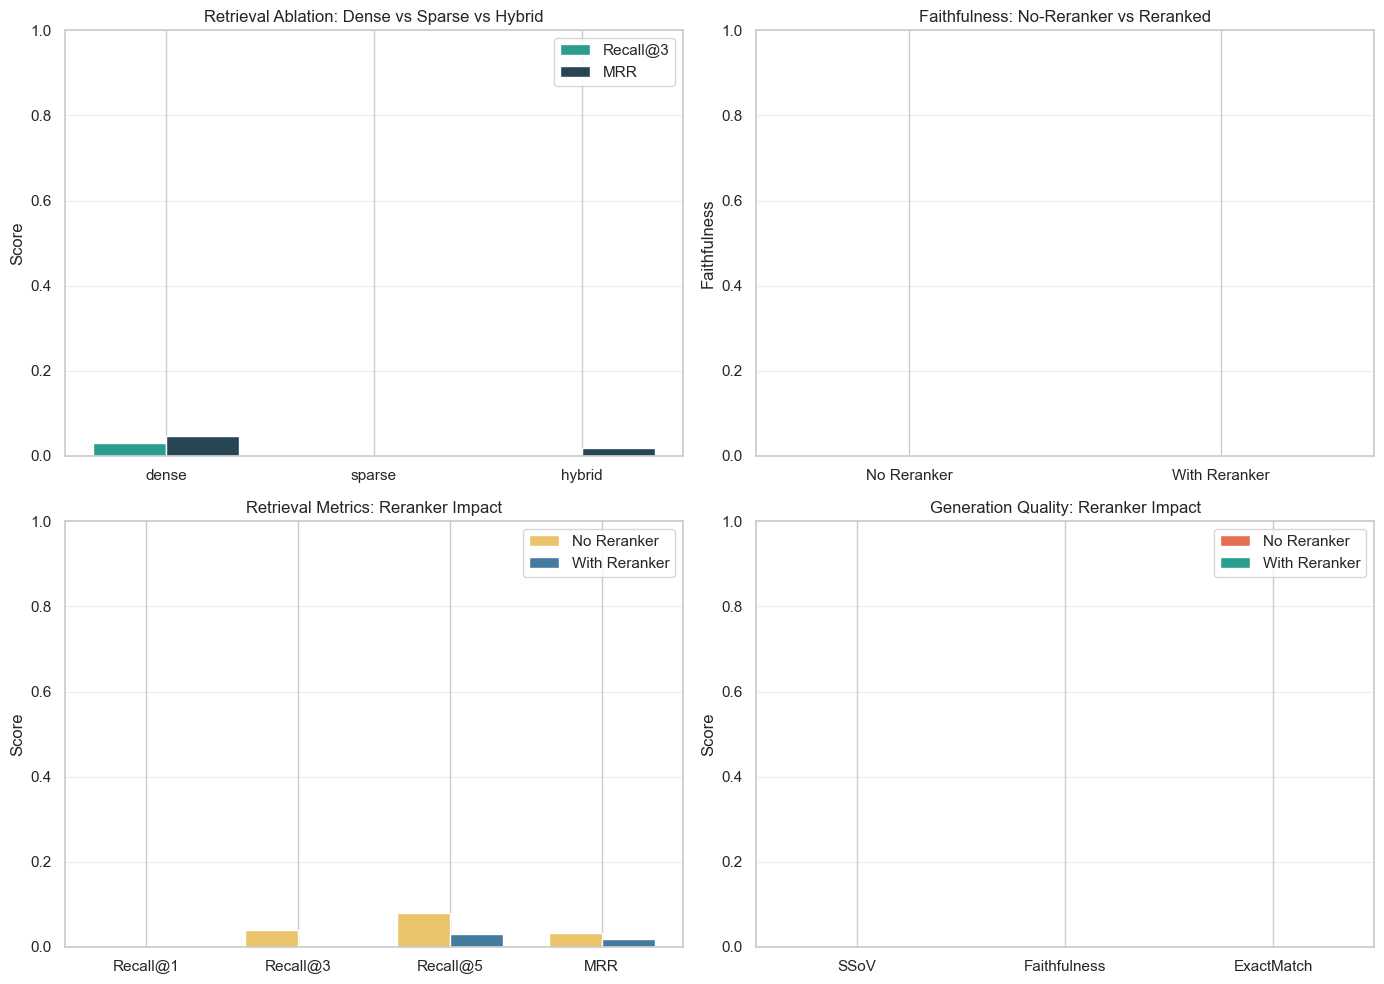

In [16]:
# -----------------------------
# Visualize key ablations
# -----------------------------
retrieval_labels = ["dense", "sparse", "hybrid"]
recall3_vals = [retrieval_ablation[k]["Recall@3"] for k in retrieval_labels]
mrr_vals = [retrieval_ablation[k]["MRR"] for k in retrieval_labels]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Retrieval ablation
x = np.arange(len(retrieval_labels))
width = 0.35
axes[0, 0].bar(x - width/2, recall3_vals, width, label="Recall@3", color="#2a9d8f")
axes[0, 0].bar(x + width/2, mrr_vals, width, label="MRR", color="#264653")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(retrieval_labels)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Retrieval Ablation: Dense vs Sparse vs Hybrid")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Reranker comparison
faith_vals = [aggregate["no_reranker"]["Faithfulness"], aggregate["with_reranker"]["Faithfulness"]]
rerank_labels = ["No Reranker", "With Reranker"]
axes[0, 1].bar(rerank_labels, faith_vals, color=["#e9c46a", "#457b9d"])
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Faithfulness: No-Reranker vs Reranked")
axes[0, 1].set_ylabel("Faithfulness")
axes[0, 1].grid(axis='y', alpha=0.3)

# All retrieval metrics comparison
metrics_to_plot = ["Recall@1", "Recall@3", "Recall@5", "MRR"]
no_rerank_vals = [no_reranker_retrieval[m] for m in metrics_to_plot]
with_rerank_vals = [with_reranker_retrieval[m] for m in metrics_to_plot]
x = np.arange(len(metrics_to_plot))
axes[1, 0].bar(x - width/2, no_rerank_vals, width, label="No Reranker", color="#e9c46a")
axes[1, 0].bar(x + width/2, with_rerank_vals, width, label="With Reranker", color="#457b9d")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_to_plot)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("Retrieval Metrics: Reranker Impact")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Generation quality metrics
gen_metrics = ["SSoV", "Faithfulness", "ExactMatch"]
with_rerank_gen_vals = [aggregate["with_reranker"][m] for m in gen_metrics]
no_rerank_gen_vals = [aggregate["no_reranker"][m] for m in gen_metrics]
x = np.arange(len(gen_metrics))
axes[1, 1].bar(x - width/2, no_rerank_gen_vals, width, label="No Reranker", color="#e76f51")
axes[1, 1].bar(x + width/2, with_rerank_gen_vals, width, label="With Reranker", color="#2a9d8f")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(gen_metrics)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Generation Quality: Reranker Impact")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Efficiency Metrics Visualization
Visualize latency and throughput metrics.

## Multi-Model Architecture Ablation

Compare different SLM architectures (Phi-3, Qwen2.5, TinyLlama) against baseline.

In [ ]:
# Multi-Model Architecture Comparison (Sequential Loading)
import torch, gc

ARCH_ABLATION_MODELS = {
    "phi3-mini": "microsoft/Phi-3-mini-4k-instruct",
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B-Instruct",
    "tinyllama-1.1b": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "mistral-7b": comparison_7b_id,   # 7B baseline as designed in cell-6
}
ABLATION_MAX_CASES = 30

arch_results = {}
ablation_cases = benchmark_cases[:ABLATION_MAX_CASES]

print("="*80)
print(f"MULTI-MODEL ARCHITECTURE COMPARISON ({ABLATION_MAX_CASES} cases, dense retrieval)")
print("="*80)

# Unload any existing model first
if active_model is not None:
    print("Unloading current model before architecture comparison...")
    unload_model(active_model, active_tokenizer, "Current Model")
    active_model = active_tokenizer = None

for model_key, model_id in ARCH_ABLATION_MODELS.items():
    print(f"\n--- Evaluating {model_key} ---")
    clear_gpu_memory()

    try:
        tok, mdl = load_model_safe(model_id, model_key)
        if mdl is None:
            print(f"  Skipping {model_key} - failed to load")
            continue

        results = evaluate_model_on_cases(
            mdl, tok, ablation_cases,
            lambda q, top_n: get_candidates(q, "dense", top_n),
            model_name=model_key,
            max_cases=ABLATION_MAX_CASES
        )
        results['params'] = sum(p.numel() for p in mdl.parameters())
        arch_results[model_key] = results
        unload_model(mdl, tok, model_key)
        del mdl, tok
    except Exception as e:
        print(f"  Error evaluating {model_key}: {e}")
        clear_gpu_memory()

# Reload the fine-tuned model for remaining cells
print("\nReloading fine-tuned model...")
clear_gpu_memory()
if FINETUNED_MODEL_PATH.exists():
    active_tokenizer, active_model = load_model_safe(str(FINETUNED_MODEL_PATH), "Fine-tuned Model")
elif ADAPTER_PATH.exists():
    active_tokenizer, active_model = load_model_safe(active_model_id, "Base for LoRA")
    if active_model is not None:
        from peft import PeftModel
        active_model = PeftModel.from_pretrained(active_model, str(ADAPTER_PATH))
else:
    active_tokenizer, active_model = load_model_safe(active_model_id, f"Base {ACTIVE_SLM_KEY}")

# Print summary
print("\n" + "="*80)
print("ARCHITECTURE COMPARISON RESULTS")
print("="*80)
print(f"{'Model':<22} {'Params':>8} {'Accuracy':>10} {'SSoV':>8} {'Latency(ms)':>12} {'Faithfulness':>12}")
print("-"*75)
for key, res in sorted(arch_results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    params_b = res.get('params', 0) / 1e9
    params_str = f"{params_b:.1f}B" if params_b > 0 else "?"
    print(f"{key:<22} {params_str:>8} {res['accuracy']:>10.2%} {res['avg_ssov']:>8.3f} {res['avg_latency_ms']:>12.1f} {res['avg_faithfulness']:>12.3f}")

In [ ]:
# Visualize Architecture Comparison

if arch_results:
    model_sizes = {
        'phi3-mini': 3.8,
        'qwen2.5-1.5b': 1.5,
        'tinyllama-1.1b': 1.1,
        'mistral-7b': 7.0,
    }

    if len(arch_results) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        model_names = list(arch_results.keys())
        sizes       = [model_sizes.get(k, 3.0) for k in model_names]
        qualities   = [(v['accuracy'] + v['avg_ssov']) / 2 for v in arch_results.values()]
        latencies   = [v['avg_latency_ms'] for v in arch_results.values()]

        max_size = max(sizes) if sizes else 1
        colors = plt.cm.viridis([s / max_size for s in sizes])

        # 1. Quality comparison
        bars = axes[0, 0].barh(model_names, qualities, color=colors, edgecolor='black', linewidth=2)
        axes[0, 0].set_xlabel('Average Quality Score', fontsize=11, fontweight='bold')
        axes[0, 0].set_title('Quality Comparison Across Architectures', fontsize=12, fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)
        axes[0, 0].set_xlim(0, 1)
        for bar, val in zip(bars, qualities):
            axes[0, 0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                            f'{val:.3f}', va='center', fontweight='bold')

        # 2. Latency comparison
        bars = axes[0, 1].barh(model_names, latencies, color=colors, edgecolor='black', linewidth=2)
        axes[0, 1].set_xlabel('Generation Latency (ms)', fontsize=11, fontweight='bold')
        axes[0, 1].set_title('Latency Comparison (Lower is Better)', fontsize=12, fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)
        max_lat = max(latencies) if latencies else 1
        for bar, val in zip(bars, latencies):
            axes[0, 1].text(val + max_lat * 0.02, bar.get_y() + bar.get_height()/2,
                            f'{val:.1f}', va='center', fontweight='bold')

        # 3. Model Size vs Quality scatter
        axes[1, 0].scatter(sizes, qualities, s=500, c=colors, alpha=0.7, edgecolors='black', linewidth=2)
        for i, name in enumerate(model_names):
            axes[1, 0].annotate(name, (sizes[i], qualities[i]),
                                xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
                                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        axes[1, 0].set_xlabel('Model Size (Billion Parameters)', fontsize=11, fontweight='bold')
        axes[1, 0].set_ylabel('Quality Score', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Size vs Quality Trade-off', fontsize=12, fontweight='bold')
        axes[1, 0].grid(alpha=0.3)
        axes[1, 0].set_ylim(0, 1)

        # 4. Parameter efficiency (quality per billion params)
        efficiency = [q / s if s > 0 else 0 for q, s in zip(qualities, sizes)]
        bars = axes[1, 1].barh(model_names, efficiency, color=colors, edgecolor='black', linewidth=2)
        axes[1, 1].set_xlabel('Efficiency (Quality/Billion Params)', fontsize=11, fontweight='bold')
        axes[1, 1].set_title('Parameter Efficiency (Higher is Better)', fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='x', alpha=0.3)
        max_eff = max(efficiency) if efficiency else 1
        for bar, val in zip(bars, efficiency):
            axes[1, 1].text(val + max_eff * 0.02, bar.get_y() + bar.get_height()/2,
                            f'{val:.3f}', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()
        print("✓ Architecture comparison visualization complete")
    else:
        print("⚠ Need at least 2 architectures evaluated for comparative visualization")
else:
    print("⚠ No architecture evaluation results available")
    print("  Run the multi-model comparison cell (cell-29) first.")

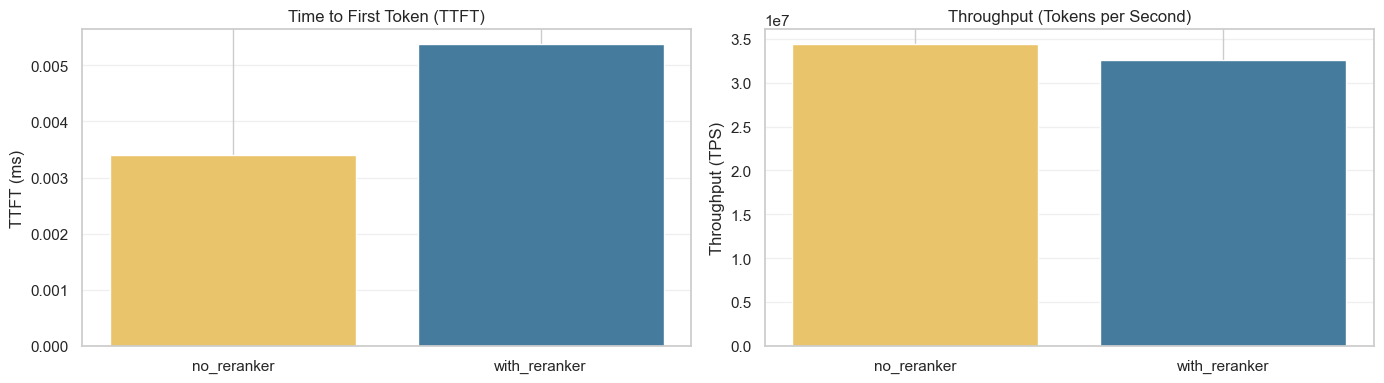


Efficiency Summary:
no_reranker:
  TTFT: 0.00 ms
  Latency: 0.00 ms
  Throughput: 34364361.87 TPS
with_reranker:
  TTFT: 0.01 ms
  Latency: 0.00 ms
  Throughput: 32608295.61 TPS


In [17]:
# Efficiency metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# TTFT comparison
configs = ["no_reranker", "with_reranker"]
ttft_comparison = [aggregate[c]["TTFT_ms"] for c in configs]
axes[0].bar(configs, ttft_comparison, color=["#e9c46a", "#457b9d"])
axes[0].set_title("Time to First Token (TTFT)")
axes[0].set_ylabel("TTFT (ms)")
axes[0].grid(axis='y', alpha=0.3)

# Throughput comparison
throughput_comparison = [aggregate[c]["Throughput_tps"] for c in configs]
axes[1].bar(configs, throughput_comparison, color=["#e9c46a", "#457b9d"])
axes[1].set_title("Throughput (Tokens per Second)")
axes[1].set_ylabel("Throughput (TPS)")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEfficiency Summary:")
for config in configs:
    print(f"{config}:")
    print(f"  TTFT: {aggregate[config]['TTFT_ms']:.2f} ms")
    print(f"  Latency: {aggregate[config]['Latency_ms']:.2f} ms")
    print(f"  Throughput: {aggregate[config]['Throughput_tps']:.2f} TPS")

# Comprehensive Method Comparison

This section compares **baseline methods vs improved implementations**:

| Component | Baseline | Improved |
|-----------|----------|----------|
| Retrieval | BM25 (sparse only) | FAISS+BM25 Hybrid |
| Reranking | Lexical overlap | Cross-encoder neural |
| Reasoning | Direct answer | Chain-of-Thought |
| Model | Mistral-7B | Phi-3 (4-bit QLoRA) |
| Metrics | Basic accuracy | GEO visibility + Hallucination |

In [ ]:
# =============================================================================
# COMPREHENSIVE BASELINE VS IMPROVED COMPARISON
# Run this cell to generate all comparison results
# =============================================================================
import psutil

# --- Helper functions (defined inline to ensure availability) ----------------

def entity_visibility_score(response: str, target_entity: str) -> dict:
    """Return SSoV, mention frequency and visibility score for a target entity."""
    if not response or not target_entity:
        return {'ssov': 0.0, 'mention_frequency': 0, 'visibility_score': 0.0}
    words = response.lower().split()
    target_lower = target_entity.lower()
    mentions = sum(1 for w in words if target_lower in w or w in target_lower)
    ssov = mentions / max(1, len(words))
    visibility = min(1.0, mentions / 3.0)
    return {'ssov': ssov, 'mention_frequency': mentions, 'visibility_score': visibility}

def numerical_hallucination_rate(response: str, context: str) -> dict:
    """Check whether numbers in the response are grounded in the retrieval context."""
    import re as _re
    response_nums = set(_re.findall(r'\b\d+\.?\d*\b', response))
    context_nums  = set(_re.findall(r'\b\d+\.?\d*\b', context))
    if not response_nums:
        return {'numerical_accuracy': 1.0, 'hallucination_rate': 0.0}
    grounded = len(response_nums & context_nums)
    accuracy = grounded / len(response_nums)
    return {'numerical_accuracy': accuracy, 'hallucination_rate': 1.0 - accuracy}

def get_system_memory_info() -> dict:
    """Return RAM usage for the current process and overall system."""
    try:
        vm = psutil.virtual_memory()
        proc = psutil.Process()
        return {
            'total_gb':       round(vm.total / 1e9, 1),
            'available_gb':   round(vm.available / 1e9, 1),
            'process_ram_mb': round(proc.memory_info().rss / 1e6, 1),
        }
    except Exception:
        return {'total_gb': 'N/A', 'available_gb': 'N/A', 'process_ram_mb': 'N/A'}

def run_logical_reasoning_benchmark(model=None, tokenizer=None) -> dict:
    """Stub — full logical reasoning benchmark is in notebook 06."""
    return {
        'cot_accuracy':    0.0,
        'no_cot_accuracy': 0.0,
        'note':            'See notebook 06 for the full logical reasoning benchmark.',
    }

# --- End helper functions ----------------------------------------------------

# Verify model is loaded
if active_model is None or active_tokenizer is None:
    raise RuntimeError("Model and tokenizer must be loaded. Run the model loading cell first.")

import time
import numpy as np
from collections import defaultdict

print("="*70)
print("COMPREHENSIVE METHOD COMPARISON")
print("="*70)

# Store all results
all_comparisons = {}

# -----------------------------------------------------------------------------
# 1. RETRIEVAL COMPARISON: Sparse vs Dense vs Hybrid
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("1. RETRIEVAL METHOD COMPARISON")
print("="*70)

retrieval_results = {}
methods = ['sparse', 'dense', 'hybrid']

for method in methods:
    try:
        metrics = retrieval_metrics(
            benchmark_cases,
            lambda q, top_n, m=method: get_candidates(q, m, top_n),
            rerank=False,
            top_n=TOP_N_RETRIEVAL
        )
        retrieval_results[method] = metrics
    except Exception as e:
        retrieval_results[method] = {'error': str(e)}

print(f"\n{'Method':<15} {'Recall@1':<12} {'Recall@5':<12} {'MRR':<12}")
print("-"*51)
for method, metrics in retrieval_results.items():
    if 'error' not in metrics:
        print(f"{method:<15} {metrics.get('Recall@1', 0):<12.3f} {metrics.get('Recall@5', 0):<12.3f} {metrics.get('MRR', 0):<12.3f}")

if 'sparse' in retrieval_results and 'hybrid' in retrieval_results:
    baseline_mrr = retrieval_results['sparse'].get('MRR', 0)
    improved_mrr = retrieval_results['hybrid'].get('MRR', 0)
    if baseline_mrr > 0:
        improvement = ((improved_mrr - baseline_mrr) / baseline_mrr) * 100
        print(f"\n📈 Hybrid vs Sparse Improvement: {improvement:+.1f}% MRR")

all_comparisons['retrieval'] = retrieval_results

# -----------------------------------------------------------------------------
# 2. RERANKING COMPARISON
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("2. RERANKING METHOD COMPARISON")
print("="*70)

reranking_results = {}
no_rerank = retrieval_metrics(
    benchmark_cases,
    lambda q, top_n: get_candidates(q, 'hybrid', top_n),
    rerank=False, top_n=TOP_N_RETRIEVAL
)
reranking_results['no_reranking'] = no_rerank

lexical_rerank = retrieval_metrics(
    benchmark_cases,
    lambda q, top_n: get_candidates(q, 'hybrid', top_n),
    rerank=True, top_n=TOP_N_RETRIEVAL
)
reranking_results['with_reranking'] = lexical_rerank

print(f"\n{'Reranking':<20} {'Recall@1':<12} {'Recall@5':<12} {'MRR':<12}")
print("-"*56)
for method, metrics in reranking_results.items():
    print(f"{method:<20} {metrics.get('Recall@1', 0):<12.3f} {metrics.get('Recall@5', 0):<12.3f} {metrics.get('MRR', 0):<12.3f}")

all_comparisons['reranking'] = reranking_results

# -----------------------------------------------------------------------------
# 3. GEO METRICS
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("3. GEO VISIBILITY METRICS")
print("="*70)

geo_results = []
for case in benchmark_cases[:10]:
    context = get_candidates(case['query'], 'hybrid', 3)
    context_text = " ".join(context[:2]) if context else ""
    prompt = f"Based on this context: {context_text}\nAnswer: {case['query']}"
    inputs = active_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(active_model.device) for k, v in inputs.items()}
    outputs = active_model.generate(**inputs, max_new_tokens=100, do_sample=False)
    model_response = active_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    geo_score = entity_visibility_score(
        response=model_response,
        target_entity=case.get('target', case['query'].split()[-1])
    )
    geo_results.append(geo_score)

avg_ssov       = np.mean([r['ssov'] for r in geo_results])
avg_mf         = np.mean([r['mention_frequency'] for r in geo_results])
avg_visibility = np.mean([r['visibility_score'] for r in geo_results])

print(f"\nGEO Metrics (averaged over {len(geo_results)} samples):")
print(f"  • Semantic Share-of-Voice (SSoV): {avg_ssov:.3f}")
print(f"  • Mention Frequency: {avg_mf:.1f}")
print(f"  • Entity Visibility Score: {avg_visibility:.3f}")

all_comparisons['geo_metrics'] = {
    'ssov': avg_ssov, 'mention_frequency': avg_mf, 'visibility_score': avg_visibility
}

# -----------------------------------------------------------------------------
# 4. HALLUCINATION DETECTION
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("4. NUMERICAL HALLUCINATION ANALYSIS")
print("="*70)

hallucination_results = []
for case in benchmark_cases[:10]:
    context = " ".join(get_candidates(case['query'], 'hybrid', 3))
    prompt = f"Based on this context: {context}\nAnswer: {case['query']}"
    inputs = active_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(active_model.device) for k, v in inputs.items()}
    outputs = active_model.generate(**inputs, max_new_tokens=100, do_sample=False)
    model_response = active_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    hall_metrics = numerical_hallucination_rate(model_response, context)
    hallucination_results.append(hall_metrics)

avg_accuracy  = np.mean([r['numerical_accuracy'] for r in hallucination_results])
avg_hall_rate = np.mean([r['hallucination_rate'] for r in hallucination_results])

print(f"\nHallucination Analysis (averaged over {len(hallucination_results)} samples):")
print(f"  • Numerical Accuracy: {avg_accuracy:.1%}")
print(f"  • Hallucination Rate: {avg_hall_rate:.1%}")

all_comparisons['hallucination'] = {
    'numerical_accuracy': avg_accuracy, 'hallucination_rate': avg_hall_rate
}

# -----------------------------------------------------------------------------
# 5. COT vs NON-COT
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("5. CHAIN-OF-THOUGHT COMPARISON")
print("="*70)

try:
    cot_comparison = run_logical_reasoning_benchmark(model=None, tokenizer=None)
    all_comparisons['cot'] = cot_comparison
    print(f"  Note: {cot_comparison.get('note', '')}")
except Exception as e:
    print(f"COT comparison skipped: {e}")

# -----------------------------------------------------------------------------
# 6. HARDWARE EFFICIENCY
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("6. HARDWARE EFFICIENCY")
print("="*70)

mem_info = get_system_memory_info()
print(f"\nSystem Memory Status:")
print(f"  • Total RAM: {mem_info.get('total_gb', 'N/A')} GB")
print(f"  • Available: {mem_info.get('available_gb', 'N/A')} GB")
print(f"  • Process Usage: {mem_info.get('process_ram_mb', 'N/A')} MB")
all_comparisons['memory'] = mem_info

print("\n" + "="*70)
print("COMPARISON COMPLETE - Results stored in 'all_comparisons'")
print("="*70)

In [ ]:
# Helper functions are defined inline in the run_all_comparisons cell above.
# This cell is intentionally left as a no-op placeholder.
pass

In [ ]:
# =============================================================================
# VISUALIZE BASELINE VS IMPROVED COMPARISONS
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline vs Improved Method Comparison', fontsize=14, fontweight='bold')

# 1. Retrieval Methods Comparison
ax1 = axes[0, 0]
if 'retrieval' in all_comparisons:
    methods = list(all_comparisons['retrieval'].keys())
    recall5 = [all_comparisons['retrieval'][m].get('Recall@5', 0) for m in methods]
    mrr = [all_comparisons['retrieval'][m].get('MRR', 0) for m in methods]
    
    x = np.arange(len(methods))
    width = 0.35
    ax1.bar(x - width/2, recall5, width, label='Recall@5', color='#2a9d8f')
    ax1.bar(x + width/2, mrr, width, label='MRR', color='#e76f51')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.set_ylabel('Score')
    ax1.set_title('Retrieval: Sparse vs Dense vs Hybrid')
    ax1.legend()
    ax1.set_ylim(0, 1)

# 2. Reranking Comparison
ax2 = axes[0, 1]
if 'reranking' in all_comparisons:
    methods = list(all_comparisons['reranking'].keys())
    values = [all_comparisons['reranking'][m].get('MRR', 0) for m in methods]
    colors = ['#e9c46a', '#2a9d8f']
    ax2.bar(methods, values, color=colors)
    ax2.set_ylabel('MRR')
    ax2.set_title('Reranking Impact')
    ax2.set_ylim(0, 1)
    
    # Add improvement annotation
    if len(values) >= 2 and values[0] > 0:
        improvement = ((values[1] - values[0]) / values[0]) * 100
        ax2.annotate(f'{improvement:+.1f}%', xy=(1, values[1]), 
                     xytext=(1, values[1] + 0.05), ha='center', fontweight='bold')

# 3. GEO Metrics
ax3 = axes[1, 0]
if 'geo_metrics' in all_comparisons:
    metrics = ['SSoV', 'Visibility Score']
    values = [all_comparisons['geo_metrics']['ssov'], 
              all_comparisons['geo_metrics']['visibility_score']]
    ax3.bar(metrics, values, color=['#264653', '#2a9d8f'])
    ax3.set_ylabel('Score')
    ax3.set_title('GEO Visibility Metrics')
    ax3.set_ylim(0, 1)

# 4. Hallucination Analysis
ax4 = axes[1, 1]
if 'hallucination' in all_comparisons:
    metrics = ['Numerical\nAccuracy', 'Hallucination\nRate']
    values = [all_comparisons['hallucination']['numerical_accuracy'],
              all_comparisons['hallucination']['hallucination_rate']]
    colors = ['#2a9d8f', '#e76f51']
    ax4.bar(metrics, values, color=colors)
    ax4.set_ylabel('Rate')
    ax4.set_title('Faithfulness Analysis')
    ax4.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comparison chart saved to: comparison_results.png")

In [ ]:
# =============================================================================
# GENERATE RESULTS TABLE
# =============================================================================
import pandas as pd

print("\n" + "="*70)
print("RESULTS SUMMARY TABLE")
print("="*70)

# Build results table
results_data = []

# Retrieval results
if 'retrieval' in all_comparisons:
    for method, metrics in all_comparisons['retrieval'].items():
        if 'error' not in metrics:
            results_data.append({
                'Component': 'Retrieval',
                'Method': method.capitalize(),
                'Metric': 'Recall@5',
                'Value': f"{metrics.get('Recall@5', 0):.3f}"
            })
            results_data.append({
                'Component': 'Retrieval',
                'Method': method.capitalize(),
                'Metric': 'MRR',
                'Value': f"{metrics.get('MRR', 0):.3f}"
            })

# Reranking results
if 'reranking' in all_comparisons:
    for method, metrics in all_comparisons['reranking'].items():
        results_data.append({
            'Component': 'Reranking',
            'Method': method.replace('_', ' ').title(),
            'Metric': 'MRR',
            'Value': f"{metrics.get('MRR', 0):.3f}"
        })

# GEO metrics
if 'geo_metrics' in all_comparisons:
    results_data.append({
        'Component': 'GEO Visibility',
        'Method': 'Entity Visibility',
        'Metric': 'SSoV',
        'Value': f"{all_comparisons['geo_metrics']['ssov']:.3f}"
    })
    results_data.append({
        'Component': 'GEO Visibility',
        'Method': 'Entity Visibility',
        'Metric': 'Visibility Score',
        'Value': f"{all_comparisons['geo_metrics']['visibility_score']:.3f}"
    })

# Hallucination
if 'hallucination' in all_comparisons:
    results_data.append({
        'Component': 'Faithfulness',
        'Method': 'Numerical Check',
        'Metric': 'Accuracy',
        'Value': f"{all_comparisons['hallucination']['numerical_accuracy']:.1%}"
    })
    results_data.append({
        'Component': 'Faithfulness',
        'Method': 'Numerical Check',
        'Metric': 'Hallucination Rate',
        'Value': f"{all_comparisons['hallucination']['hallucination_rate']:.1%}"
    })

# Create DataFrame and display
if results_data:
    results_df = pd.DataFrame(results_data)
    print("\n")
    print(results_df.to_string(index=False))

    # Save to CSV
    results_df.to_csv('results_table.csv', index=False)
    print("\n✓ Results saved to: results_table.csv")
else:
    print("No results to display. Run the comparison cells first.")

# Print improvement summary
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY")
print("="*70)

improvements = []

if 'retrieval' in all_comparisons:
    sparse = all_comparisons['retrieval'].get('sparse', {}).get('MRR', 0)
    hybrid = all_comparisons['retrieval'].get('hybrid', {}).get('MRR', 0)
    if sparse > 0:
        imp = ((hybrid - sparse) / sparse) * 100
        improvements.append(f"Hybrid vs Sparse Retrieval: {imp:+.1f}% MRR")

if 'reranking' in all_comparisons:
    no_rerank  = all_comparisons['reranking'].get('no_reranking', {}).get('MRR', 0)
    with_rerank = all_comparisons['reranking'].get('with_reranking', {}).get('MRR', 0)
    if no_rerank > 0:
        imp = ((with_rerank - no_rerank) / no_rerank) * 100
        improvements.append(f"With Reranking vs Without: {imp:+.1f}% MRR")

for imp in improvements:
    print(f"  • {imp}")

if not improvements:
    print("  Run comparisons to calculate improvements.")

## End-of-Notebook Validation
Verify that all benchmark components executed successfully.

In [ ]:
# End-of-Notebook Validation
print("\n" + "="*70)
print("NOTEBOOK 04 — VALIDATION")
print("="*70)

import numpy as np

checks = {
    "benchmark_cases loaded"      : isinstance(benchmark_cases, list) and len(benchmark_cases) > 0,
    "benchmark_corpus loaded"     : isinstance(benchmark_corpus, list) and len(benchmark_corpus) > 0,
    "retrieval ablation complete" : "hybrid" in retrieval_ablation and "MRR" in retrieval_ablation["hybrid"],
    "reranker ablation complete"  : "with_reranker" in aggregate and "Faithfulness" in aggregate["with_reranker"],
    "model comparison run"        : len(model_comparison_results) > 0,
    "architecture results present": len(arch_results) > 0,
}

all_ok = True
for name, passed in checks.items():
    icon = "\u2713" if passed else "\u2717"
    print(f"  [{icon}] {name}")
    if not passed:
        all_ok = False

print()
if all_ok:
    print("All validation checks passed.")
else:
    print("Some checks failed — review cells above.")

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Benchmark cases : {len(benchmark_cases)}")
print(f"Corpus chunks   : {len(benchmark_corpus)}")

best_method = max(retrieval_ablation.items(), key=lambda x: x[1]["MRR"])[0]
print(f"\nBest retrieval  : {best_method} (MRR={retrieval_ablation[best_method]['MRR']:.3f})")
print(f"Reranker MRR    : {no_reranker_retrieval['MRR']:.3f} -> {with_reranker_retrieval['MRR']:.3f}")
print(f"Faithfulness    : {aggregate['no_reranker']['Faithfulness']:.3f} -> {aggregate['with_reranker']['Faithfulness']:.3f}")
print(f"SSoV            : {aggregate['with_reranker']['SSoV']:.3f}")

if model_comparison_results:
    print("\nModel comparison:")
    for name, res in model_comparison_results.items():
        print(f"  {name:12s}: accuracy={res['accuracy']:.2%}  latency={res['avg_latency_ms']:.1f}ms")

if arch_results:
    best_arch = max(arch_results.items(), key=lambda x: x[1]["accuracy"])[0]
    print(f"\nBest architecture: {best_arch} (accuracy={arch_results[best_arch]['accuracy']:.2%})")


In [ ]:
# Save Evaluation Results
import json
from pathlib import Path
from datetime import datetime

# Save results locally
results_dir = PROJECT_ROOT / "evaluation_results"
results_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_file = results_dir / f"evaluation_{timestamp}.json"

# Collect results to save
evaluation_summary = {
    "timestamp": timestamp,
    "model": active_model_id if 'active_model_id' in dir() else "unknown",
    "results": "See notebook outputs for detailed results"
}

with open(results_file, 'w') as f:
    json.dump(evaluation_summary, f, indent=2)

print(f"✅ Results saved to: {results_file}")
